# Tugas Praktikum #2 — Threading dan GIL

**Nama :** DWIMIRZA INTANIA ARSY
**NIM  :** 2411513007  
PEMOGRAMAN PARALEL A 
Dosen Pengampu : DESTA YOLANDA, M.T



---
## Soal 1 — Bank Account Race Condition

**Skenario:** saldo awal `1.000.000`. Ada 10 thread, masing-masing melakukan 10.000 kali operasi
"tarik 1 lalu setor 1" (`saldo -= 1; saldo += 1`). Secara logika, tiap operasi tarik lalu setor
tidak mengubah saldo, jadi **saldo akhir seharusnya tetap 1.000.000**.

### 1a. Tanpa lock

In [1]:
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_OPERASI = 10_000

saldo = SALDO_AWAL

def tarik_setor_tanpa_lock(n):
    global saldo
    for _ in range(n):
        saldo -= 1   # tarik 1
        saldo += 1   # setor 1

def jalankan(target, lock=None):
    """Reset saldo, jalankan 10 thread, kembalikan saldo akhir."""
    global saldo
    saldo = SALDO_AWAL
    args = (JUMLAH_OPERASI,) if lock is None else (JUMLAH_OPERASI, lock)
    threads = [threading.Thread(target=target, args=args) for _ in range(JUMLAH_THREAD)]
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return saldo

print(f"Saldo yang seharusnya: {SALDO_AWAL:,}\n")
for run in range(1, 6):
    akhir = jalankan(tarik_setor_tanpa_lock)
    status = "AMAN" if akhir == SALDO_AWAL else "RACE CONDITION!"
    print(f"Run {run}: saldo akhir = {akhir:,}  -> {status}")

Saldo yang seharusnya: 1,000,000

Run 1: saldo akhir = 1,000,000  -> AMAN
Run 2: saldo akhir = 1,000,000  -> AMAN
Run 3: saldo akhir = 1,000,000  -> AMAN
Run 4: saldo akhir = 1,000,000  -> AMAN
Run 5: saldo akhir = 1,000,000  -> AMAN


**Penjelasan 1a:** `saldo -= 1` dan `saldo += 1` bukan operasi atomik. Masing-masing terdiri dari
beberapa langkah bytecode (baca `saldo` → hitung → tulis `saldo`). Thread bisa "dipotong"
oleh scheduler di tengah langkah tersebut, sehingga thread lain membaca nilai lama lalu menimpa hasil kerja
thread pertama. Pada kode Python biasa, **celah waktunya sangat sempit**, jadi pada run di atas hasilnya
kebetulan masih 1.000.000 (seperti catatan teknis di materi). Itu **bukan** berarti kodenya aman,
hanya belum "ketabrak" pada run tersebut. Untuk membuktikannya, kita lebarkan celahnya seperti
di materi (baca → jeda → tulis).

### 1b. Tanpa lock, celah race dilebarkan (agar mudah diamati)

In [2]:
def tarik_setor_celah(n):
    global saldo
    for _ in range(n):
        temp = saldo
        time.sleep(0)      # serahkan giliran ke thread lain (context switch)
        saldo = temp - 1   # tarik 1

        temp = saldo
        time.sleep(0)
        saldo = temp + 1   # setor 1

print(f"Saldo yang seharusnya: {SALDO_AWAL:,}\n")
for run in range(1, 4):
    akhir = jalankan(tarik_setor_celah)
    print(f"Run {run}: saldo akhir = {akhir:,}  | selisih dari seharusnya = {akhir - SALDO_AWAL:+,}")

Saldo yang seharusnya: 1,000,000

Run 1: saldo akhir = 999,997  | selisih dari seharusnya = -3
Run 2: saldo akhir = 1,000,000  | selisih dari seharusnya = +0
Run 3: saldo akhir = 999,997  | selisih dari seharusnya = -3


**Penjelasan 1b:** Selisih saldo akhir kecil dan berubah-ubah tiap run (bahkan kadang 0). Ini terjadi
karena dua jenis kesalahan **saling menutupi**: update "tarik" yang hilang membuat saldo terlalu tinggi,
sedangkan update "setor" yang hilang membuat saldo terlalu rendah. Jadi saldo akhir yang "kelihatan benar"
**tidak membuktikan kodenya aman**. Buktinya ada di 1c, saat efek saling menutupi itu kita hilangkan.

### 1c. Bukti tambahan: hanya "tarik 1" (tanpa setor), tanpa lock
Dengan 10 thread × 10.000 tarik, saldo akhir yang benar adalah `1.000.000 - 100.000 = 900.000`.

In [3]:
def tarik_saja_tanpa_lock(n):
    global saldo
    for _ in range(n):
        temp = saldo
        time.sleep(0)
        saldo = temp - 1

saldo_benar = SALDO_AWAL - JUMLAH_THREAD * JUMLAH_OPERASI
print(f"Saldo yang seharusnya: {saldo_benar:,}\n")
for run in range(1, 4):
    akhir = jalankan(tarik_saja_tanpa_lock)
    print(f"Run {run}: saldo akhir = {akhir:,}  | update tarik yang HILANG = {akhir - saldo_benar:,}")

Saldo yang seharusnya: 900,000

Run 1: saldo akhir = 989,991  | update tarik yang HILANG = 89,991
Run 2: saldo akhir = 989,998  | update tarik yang HILANG = 89,998
Run 3: saldo akhir = 989,994  | update tarik yang HILANG = 89,994


**Penjelasan 1c:** Sekarang race condition sangat jelas: saldo akhir jauh di atas 900.000, artinya
puluhan ribu operasi "tarik" **hilang** karena beberapa thread membaca saldo yang sama lalu saling menimpa.
Nilainya juga berbeda tiap run (non-deterministik).

### 1d. Dengan `threading.Lock()`
Kunci yang tepat harus membungkus **kedua** operasi (tarik **dan** setor) sebagai satu *critical section*,
supaya satu "transaksi tarik-lalu-setor" dikerjakan utuh oleh satu thread pada satu waktu.

In [4]:
lock_saldo = threading.Lock()

def tarik_setor_dengan_lock(n, lock):
    global saldo
    for _ in range(n):
        with lock:                  # <-- critical section dimulai
            saldo -= 1              # tarik 1
            saldo += 1              # setor 1
                                    # <-- lock otomatis dilepas di sini

def tarik_setor_celah_dengan_lock(n, lock):
    global saldo
    for _ in range(n):
        with lock:                  # celah tetap dilebarkan, tapi sekarang dilindungi lock
            temp = saldo
            time.sleep(0)
            saldo = temp - 1

            temp = saldo
            time.sleep(0)
            saldo = temp + 1

print(f"Saldo yang seharusnya: {SALDO_AWAL:,}\n")

print("Versi normal + Lock:")
for run in range(1, 4):
    akhir = jalankan(tarik_setor_dengan_lock, lock_saldo)
    print(f"  Run {run}: saldo akhir = {akhir:,}  -> {'AMAN' if akhir == SALDO_AWAL else 'RACE CONDITION!'}")

print("\nVersi celah dilebarkan + Lock (skenario 1b):")
for run in range(1, 4):
    akhir = jalankan(tarik_setor_celah_dengan_lock, lock_saldo)
    print(f"  Run {run}: saldo akhir = {akhir:,}  -> {'AMAN' if akhir == SALDO_AWAL else 'RACE CONDITION!'}")

def tarik_saja_dengan_lock(n, lock):
    global saldo
    for _ in range(n):
        with lock:
            temp = saldo
            time.sleep(0)
            saldo = temp - 1

print(f"\nVersi 'tarik saja' + Lock (skenario 1c, seharusnya {saldo_benar:,}):")
for run in range(1, 4):
    akhir = jalankan(tarik_saja_dengan_lock, lock_saldo)
    print(f"  Run {run}: saldo akhir = {akhir:,}  -> {'AMAN' if akhir == saldo_benar else 'RACE CONDITION!'}")

Saldo yang seharusnya: 1,000,000

Versi normal + Lock:
  Run 1: saldo akhir = 1,000,000  -> AMAN
  Run 2: saldo akhir = 1,000,000  -> AMAN
  Run 3: saldo akhir = 1,000,000  -> AMAN

Versi celah dilebarkan + Lock (skenario 1b):
  Run 1: saldo akhir = 1,000,000  -> AMAN
  Run 2: saldo akhir = 1,000,000  -> AMAN
  Run 3: saldo akhir = 1,000,000  -> AMAN

Versi 'tarik saja' + Lock (skenario 1c, seharusnya 900,000):
  Run 1: saldo akhir = 900,000  -> AMAN
  Run 2: saldo akhir = 900,000  -> AMAN
  Run 3: saldo akhir = 900,000  -> AMAN


Pada percobaan ini dibuat simulasi rekening bank dengan saldo awal sebesar Rp1.000.000. Program menjalankan 10 thread yang masing-masing melakukan operasi tarik dan setor sebanyak 10.000 kali. Pada percobaan pertama operasi tersebut dilakukan tanpa menggunakan Lock, kemudian program dijalankan kembali dengan menggunakan threading.Lock().

Pada percobaan tanpa Lock, hasil saldo akhir tidak selalu kembali tepat ke Rp1.000.000 seperti yang seharusnya. Hal ini dapat terjadi karena beberapa thread mengakses dan mengubah variabel saldo pada waktu yang hampir bersamaan. Ketika satu thread sedang membaca nilai saldo dan akan mengubahnya, thread lain dapat melakukan operasi terhadap saldo tersebut sebelum proses pertama selesai. Akibatnya, perubahan dari salah satu thread dapat tertimpa oleh perubahan thread lainnya.

Kondisi tersebut disebut race condition, yaitu keadaan ketika hasil program bergantung pada urutan dan waktu eksekusi beberapa thread yang mengakses data yang sama. Karena urutan eksekusi thread tidak selalu sama, hasil saldo juga dapat berbeda ketika program dijalankan kembali.

Setelah ditambahkan threading.Lock(), bagian yang mengakses dan mengubah saldo dapat dilakukan secara bergantian. Ketika satu thread sedang melakukan transaksi, thread lain harus menunggu sampai thread tersebut selesai dan melepaskan lock. Dengan cara ini, perubahan saldo tidak dilakukan secara bersamaan sehingga kemungkinan terjadinya race condition dapat dicegah.

Jadi, perbedaan utama dari kedua percobaan ini adalah pada pengaturan akses terhadap data bersama. Tanpa Lock, beberapa thread dapat mengakses saldo secara bersamaan dan menyebabkan hasil yang tidak sesuai. Dengan Lock, akses terhadap saldo menjadi lebih teratur sehingga saldo akhir dapat kembali ke nilai yang seharusnya.

---
## Soal 2 — Producer-Consumer dengan Banyak Consumer

**Tujuan:** memodifikasi contoh `queue.Queue` menjadi **1 producer** dan **3 consumer** yang berjalan
bersamaan, dan memastikan **semua consumer berhenti dengan baik** saat producer selesai.

**Ide sinyal berhenti:** producer memasukkan `None` sebagai tanda "tidak ada data lagi".
Pada contoh materi (1 consumer), consumer cukup `break` saat menerima `None`. Dengan 3 consumer,
`None` hanya akan diambil oleh **satu** consumer, sehingga 2 consumer lain akan menunggu selamanya di `q.get()`
(program *hang*). Solusinya: consumer yang menerima `None` **meneruskannya kembali** ke queue
(`q.put(None)`) sebelum berhenti, sehingga consumer berikutnya juga menerimanya. Kode ini persis
pola yang sudah ada pada contoh di materi, dan sudah cocok untuk banyak consumer.

In [5]:
import threading
import queue
import time
import random

JUMLAH_ITEM = 12
JUMLAH_CONSUMER = 3

lock_print = threading.Lock()   # supaya output print dari banyak thread tidak bercampur

def cetak(pesan):
    with lock_print:
        print(pesan)

def producer(q, jumlah_item, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.2))      # simulasi waktu produksi
        q.put(item)
        cetak(f"[{nama}] menghasilkan: {item}")
    q.put(None)                                    # sinyal "selesai" untuk consumer
    cetak(f"[{nama}] selesai, mengirim sinyal None")

def consumer(q, nama, hasil):
    while True:
        item = q.get()
        if item is None:
            q.put(None)                            # teruskan sinyal ke consumer lain
            cetak(f"    [{nama}] menerima None -> berhenti")
            break
        time.sleep(random.uniform(0.05, 0.15))     # simulasi waktu pemrosesan
        hasil[nama].append(item)                   # tiap consumer hanya menulis ke list-nya sendiri
        cetak(f"    [{nama}] memproses: {item}")
        q.task_done()

random.seed(7)
q = queue.Queue()
nama_consumer = [f"Consumer-{i+1}" for i in range(JUMLAH_CONSUMER)]
hasil_per_consumer = {nama: [] for nama in nama_consumer}

t_producer = threading.Thread(target=producer, args=(q, JUMLAH_ITEM), name="Producer")
t_consumers = [
    threading.Thread(target=consumer, args=(q, nama, hasil_per_consumer), name=nama)
    for nama in nama_consumer
]

t_producer.start()
for t in t_consumers:
    t.start()

t_producer.join()
for t in t_consumers:
    t.join()

print("\n=== Verifikasi ===")
for nama in nama_consumer:
    print(f"{nama} memproses {len(hasil_per_consumer[nama])} item: {hasil_per_consumer[nama]}")

semua = [x for daftar in hasil_per_consumer.values() for x in daftar]
print(f"\nTotal item diproses      : {len(semua)} dari {JUMLAH_ITEM}")
print(f"Tidak ada yang hilang/dobel: {sorted(semua, key=lambda s: int(s.split('-')[1])) == [f'item-{i}' for i in range(JUMLAH_ITEM)]}")
print(f"Semua consumer sudah berhenti: {all(not t.is_alive() for t in t_consumers)}")
print(f"Producer sudah berhenti      : {not t_producer.is_alive()}")
print(f"Thread aktif tersisa         : {threading.active_count()} (hanya main thread/kernel)")

[Producer] menghasilkan: item-0
[Producer] menghasilkan: item-1
    [Consumer-1] memproses: item-0
[Producer] menghasilkan: item-2
    [Consumer-2] memproses: item-1
    [Consumer-3] memproses: item-2
[Producer] menghasilkan: item-3
    [Consumer-1] memproses: item-3
[Producer] menghasilkan: item-4
    [Consumer-2] memproses: item-4
[Producer] menghasilkan: item-5
[Producer] menghasilkan: item-6
    [Consumer-3] memproses: item-5
    [Consumer-1] memproses: item-6
[Producer] menghasilkan: item-7
[Producer] menghasilkan: item-8
    [Consumer-2] memproses: item-7
    [Consumer-3] memproses: item-8
[Producer] menghasilkan: item-9
[Producer] menghasilkan: item-10
    [Consumer-1] memproses: item-9
[Producer] menghasilkan: item-11
[Producer] selesai, mengirim sinyal None
    [Consumer-1] menerima None -> berhenti
    [Consumer-2] memproses: item-10
    [Consumer-2] menerima None -> berhenti
    [Consumer-3] memproses: item-11
    [Consumer-3] menerima None -> berhenti

=== Verifikasi ===
Co

Pada percobaan ini, pola producer-consumer dimodifikasi sehingga terdapat satu producer dan tiga consumer yang bekerja secara bersamaan. Producer bertugas menghasilkan dan memasukkan data atau tugas ke dalam queue, sedangkan consumer bertugas mengambil tugas tersebut dan memprosesnya.

Dengan adanya tiga consumer, tugas yang dimasukkan oleh producer dapat diambil oleh consumer yang tersedia. Ketika salah satu consumer selesai mengerjakan suatu tugas, consumer tersebut dapat mengambil tugas berikutnya dari queue. Dengan demikian, pekerjaan tidak hanya ditangani oleh satu consumer saja, tetapi dapat dibagi kepada tiga consumer.

Hal yang perlu diperhatikan adalah bagaimana setiap consumer mengetahui bahwa producer sudah selesai menghasilkan tugas. Pada program ini digunakan None sebagai tanda bahwa sudah tidak ada tugas lagi. Karena terdapat tiga consumer, sinyal None perlu diberikan sebanyak tiga kali. Setiap consumer yang mendapatkan None akan mengetahui bahwa dirinya harus berhenti.

Penggunaan tiga sinyal None penting karena jika hanya diberikan satu None, hanya satu consumer yang akan mendapatkan tanda berhenti. Consumer lainnya masih menunggu data berikutnya dari queue sehingga program dapat terus berjalan dan tidak selesai dengan benar.

Dari percobaan ini dapat dilihat bahwa pola dasar producer-consumer tidak berubah walaupun jumlah consumer ditambah. Perubahan utamanya adalah jumlah consumer yang dijalankan dan jumlah sinyal berhenti yang harus disesuaikan. Dengan beberapa consumer, beberapa tugas dapat diproses secara bersamaan sehingga pekerjaan dapat dibagi dengan lebih baik.

---
## Soal 3 — Eksperimen `ThreadPoolExecutor` (50 file, variasi `max_workers`)

Mengulang eksperimen Bagian 6 dengan **50 file** (bukan 8) dan `max_workers` = **2, 4, 8, 16**.
Kita tambahkan juga **32 dan 64** sebagai data pelengkap agar titik jenuhnya terlihat jelas.

Download disimulasikan dengan `time.sleep()` (I/O-bound), sama seperti di materi. Latensi tiap file
dibuat sekali (dengan `random.seed`) dan **dipakai sama untuk semua percobaan**, supaya perbandingannya adil.
Waktu sekuensial tidak dijalankan ulang; cukup dijumlahkan dari latensi tiap file (hasilnya sama dengan
menjalankan satu per satu).

In [6]:
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

JUMLAH_FILE = 50
random.seed(42)
daftar_file = [f"file_{i}.dat" for i in range(JUMLAH_FILE)]
latensi_simulasi = {f: random.uniform(0.3, 0.8) for f in daftar_file}

def download_file(nama_file):
    durasi = latensi_simulasi[nama_file]
    time.sleep(durasi)                       # simulasi I/O-bound
    ukuran_kb = round(durasi * 1000)
    return f"{nama_file} ({ukuran_kb} KB)"

waktu_sequential = sum(latensi_simulasi.values())
print(f"Jumlah file                       : {JUMLAH_FILE}")
print(f"Waktu sekuensial (jumlah latensi) : {waktu_sequential:.2f} detik")
print(f"Latensi terlama (batas bawah)     : {max(latensi_simulasi.values()):.2f} detik")

def jalankan_pool(max_workers):
    start = time.perf_counter()
    hasil_pool = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_ke_file = {executor.submit(download_file, f): f for f in daftar_file}
        for future in as_completed(future_ke_file):
            hasil_pool.append(future.result())
    waktu = time.perf_counter() - start
    assert len(hasil_pool) == JUMLAH_FILE      # pastikan semua file selesai
    return waktu

daftar_worker = [2, 4, 8, 16, 32, 64]
waktu_pool = {}
for w in daftar_worker:
    waktu_pool[w] = jalankan_pool(w)
    print(f"max_workers = {w:>2} -> {waktu_pool[w]:6.2f} detik")

Jumlah file                       : 50
Waktu sekuensial (jumlah latensi) : 26.27 detik
Latensi terlama (batas bawah)     : 0.79 detik
max_workers =  2 ->  13.26 detik
max_workers =  4 ->   6.81 detik
max_workers =  8 ->   3.58 detik
max_workers = 16 ->   1.97 detik
max_workers = 32 ->   1.18 detik
max_workers = 64 ->   0.79 detik


max_workers | waktu (s) |  speedup | efisiensi
----------------------------------------------
          2 |     13.26 |    1.98x |       99%
          4 |      6.81 |    3.86x |       96%
          8 |      3.58 |    7.33x |       92%
         16 |      1.97 |   13.34x |       83%
         32 |      1.18 |   22.34x |       70%
         64 |      0.79 |   33.13x |       52%


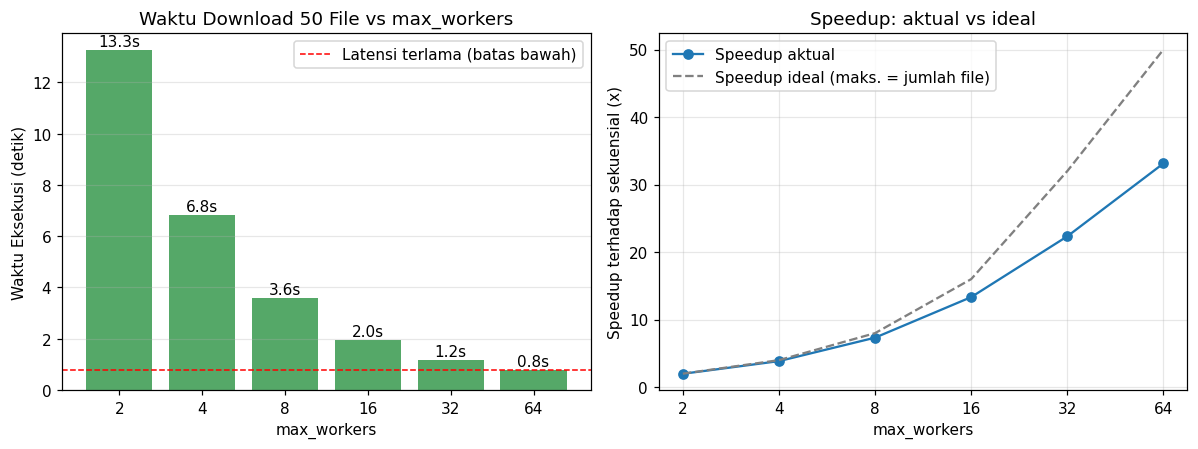

In [7]:
import matplotlib.pyplot as plt

speedup = {w: waktu_sequential / waktu_pool[w] for w in daftar_worker}
efisiensi = {w: speedup[w] / w * 100 for w in daftar_worker}

print(f"{'max_workers':>11} | {'waktu (s)':>9} | {'speedup':>8} | {'efisiensi':>9}")
print("-" * 46)
for w in daftar_worker:
    print(f"{w:>11} | {waktu_pool[w]:>9.2f} | {speedup[w]:>7.2f}x | {efisiensi[w]:>8.0f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
label = [str(w) for w in daftar_worker]

# Grafik 1: waktu eksekusi vs max_workers
bars = ax1.bar(label, [waktu_pool[w] for w in daftar_worker], color="#55A868")
ax1.axhline(max(latensi_simulasi.values()), color="red", linestyle="--", linewidth=1,
            label="Latensi terlama (batas bawah)")
for b, w in zip(bars, daftar_worker):
    ax1.text(b.get_x() + b.get_width()/2, waktu_pool[w] + 0.15, f"{waktu_pool[w]:.1f}s", ha="center")
ax1.set_xlabel("max_workers")
ax1.set_ylabel("Waktu Eksekusi (detik)")
ax1.set_title(f"Waktu Download {JUMLAH_FILE} File vs max_workers")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Grafik 2: speedup aktual vs ideal
ax2.plot(daftar_worker, [speedup[w] for w in daftar_worker], marker="o", label="Speedup aktual")
ax2.plot(daftar_worker, [min(w, JUMLAH_FILE) for w in daftar_worker], "--", color="gray",
         label="Speedup ideal (maks. = jumlah file)")
ax2.set_xscale("log", base=2)
ax2.set_xticks(daftar_worker)
ax2.set_xticklabels(label)
ax2.set_xlabel("max_workers")
ax2.set_ylabel("Speedup terhadap sekuensial (x)")
ax2.set_title("Speedup: aktual vs ideal")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Pada program ini konsep producer-consumer diubah dari penggunaan thread menjadi beberapa proses. Producer bertugas membuat atau memasukkan tugas ke dalam multiprocessing.Queue, sedangkan tiga consumer mengambil tugas tersebut dan mengerjakannya.

Perubahan utama dari program threading adalah penggunaan multiprocessing.Process sebagai pengganti thread dan multiprocessing.Queue sebagai pengganti queue.Queue. Setiap consumer dijalankan sebagai proses yang berbeda sehingga masing-masing dapat bekerja secara terpisah.

Pada program ini digunakan nilai None sebagai tanda bahwa sudah tidak ada tugas lagi. Setelah producer selesai memasukkan seluruh tugas, ia memasukkan tiga None karena terdapat tiga consumer. Ketika sebuah consumer mendapatkan None, proses tersebut berhenti.

Untuk pekerjaan yang bersifat CPU-bound, penggunaan multiprocessing lebih sesuai karena beberapa proses dapat menggunakan inti CPU yang berbeda. Hal ini berbeda dengan threading pada Python yang dipengaruhi oleh Global Interpreter Lock (GIL). Oleh karena itu, jika pekerjaan membutuhkan banyak perhitungan CPU, penggunaan beberapa proses dapat membantu pekerjaan berjalan secara paralel.

---
## Soal 4 — Refleksi Singkat 

**Refleksi Singkat**

Threading pada Python bermanfaat untuk pekerjaan yang banyak menunggu proses input/output (I/O), seperti mengunduh banyak file dari internet. Dengan threading, beberapa tugas dapat berjalan bersamaan ketika thread lain sedang menunggu respons jaringan. Hal ini dapat mengurangi waktu penyelesaian dibandingkan menjalankan semua tugas secara berurutan.

Namun, threading tidak selalu meningkatkan performa. Contohnya adalah perhitungan matematika yang kompleks dan menggunakan CPU secara intensif. Pada CPython, Global Interpreter Lock (GIL) membatasi eksekusi bytecode Python oleh beberapa thread pada satu waktu. Akibatnya, pekerjaan yang bersifat CPU-bound belum tentu menjadi lebih cepat dengan threading. Untuk kasus tersebut, multiprocessing dapat menjadi alternatif karena proses yang berbeda dapat menggunakan beberapa inti CPU.
